In [11]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

ModuleNotFoundError: No module named 'sklearn'

In [2]:
# Load the dataset
df = pd.read_csv("Toddler_Autism_dataset_July_2018.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1054 entries, 0 to 1053
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Case_No                 1054 non-null   int64 
 1   A1                      1054 non-null   int64 
 2   A2                      1054 non-null   int64 
 3   A3                      1054 non-null   int64 
 4   A4                      1054 non-null   int64 
 5   A5                      1054 non-null   int64 
 6   A6                      1054 non-null   int64 
 7   A7                      1054 non-null   int64 
 8   A8                      1054 non-null   int64 
 9   A9                      1054 non-null   int64 
 10  A10                     1054 non-null   int64 
 11  Age_Mons                1054 non-null   int64 
 12  Qchat-10-Score          1054 non-null   int64 
 13  Sex                     1054 non-null   object
 14  Ethnicity               1054 non-null   object
 15  Jaun

In [5]:
# Rename columns for clarity
df = df.rename(columns={
    'Class/ASD Traits ': 'ASD',
    'A1': 'Q1', 'A2': 'Q2', 'A3': 'Q3', 'A4': 'Q4',
    'A5': 'Q5', 'A6': 'Q6', 'A7': 'Q7', 'A8': 'Q8',
    'A9': 'Q9', 'A10': 'Q10', 'Age_Mons': 'Age in Months',
    'Sex': 'Gender', 'Qchat-10-Score': 'Score out of 10',
    'Ethnicity': 'Region'
})
df.head()

,Case_No,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Age in Months,Score out of 10,Gender,Region,Jaundice,Family_mem_with_ASD,Who completed the test,ASD
0,1,0,0,0,0,0,0,1,1,0,1,28,3,f,middle eastern,yes,no,family member,No
1,2,1,1,0,0,0,1,1,0,0,0,36,4,m,White European,yes,no,family member,Yes
2,3,1,0,0,0,0,0,1,1,0,1,36,4,m,middle eastern,yes,no,family member,Yes
3,4,1,1,1,1,1,1,1,1,1,1,24,10,m,Hispanic,no,no,family member,Yes
4,5,1,1,0,1,1,1,1,1,1,1,20,9,f,White European,no,yes,family member,Yes


In [6]:
# Prepare features and target variable
x = df.drop(columns=['Case_No', 'ASD']) # training 
y = df['ASD'] #output 

In [9]:
# Split data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=36)

ModuleNotFoundError: No module named 'sklearn'

In [6]:
# Identify categorical and numerical columns
obj_cols = x_train.select_dtypes(include='object').columns
float_cols = x_train.select_dtypes(include='int64').columns

In [7]:
# Encode target variable
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(y_train)
y_train_processed = le.transform(y_train)
y_test_processed = le.transform(y_test)

# Encode categorical features
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[x_train[col].unique() for col in obj_cols])
oe.fit(x_train[obj_cols])
x_train_cat_encoded = oe.transform(x_train[obj_cols])
x_test_cat_encoded = oe.transform(x_test[obj_cols])

In [8]:
# Scale numerical features
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x_train[float_cols])
x_train_float_encoded = scaler.transform(x_train[float_cols])
x_test_float_encoded = scaler.transform(x_test[float_cols])

# Combine processed features
x_train_processed = np.hstack((x_train_cat_encoded, x_train_float_encoded))
x_test_processed = np.hstack((x_test_cat_encoded, x_test_float_encoded))

# Get feature names
feature_names = np.concatenate([obj_cols, float_cols])

In [9]:
# Train Logistic Regression model
from sklearn.linear_model import LogisticRegression # classifaction, regression model
lr = LogisticRegression()
lr.fit(x_train_processed, y_train_processed)

# Make predictions
y_pred = lr.predict(x_test_processed)

In [10]:
# Evaluate model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

print(f'Accuracy: {accuracy_score(y_test_processed, y_pred)}')
print('Confusion Matrix:')
print(confusion_matrix(y_test_processed, y_pred))
print('Classification Report:')
print(classification_report(y_test_processed, y_pred, target_names=le.inverse_transform([0,1])))

Accuracy: 1.0
Confusion Matrix:
[[ 66   0]
 [  0 145]]
Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        66
         Yes       1.00      1.00      1.00       145

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211



<Axes: >

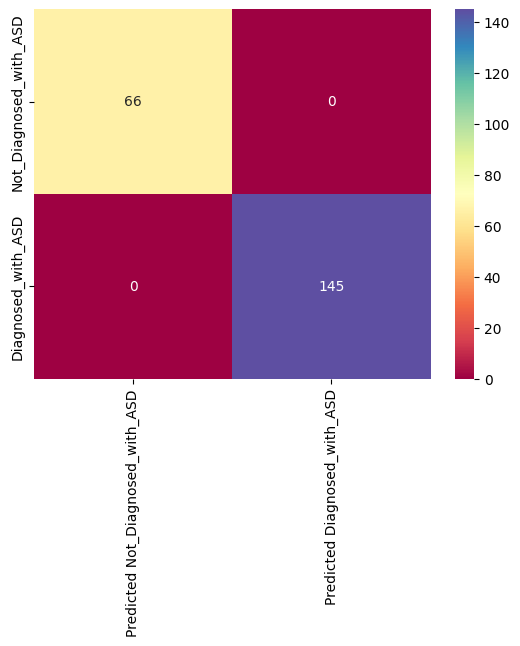

In [11]:
# Pretty confusion matrix
def pretty_confusion_matrix(y_test, y_pred, labels=['Not_Diagnosed_with_ASD', 'Diagnosed_with_ASD']):
    cm = confusion_matrix(y_test, y_pred)
    pred_labels = ['Predicted ' + i for i in labels]
    df_cm = pd.DataFrame(cm, columns=pred_labels, index=labels)
    return df_cm

results_plot = pretty_confusion_matrix(y_test_processed, y_pred, ['Not_Diagnosed_with_ASD', 'Diagnosed_with_ASD'])
sns.heatmap(results_plot, annot=True, cmap='Spectral', fmt='d')

<Axes: title={'center': 'Feature Importance'}>

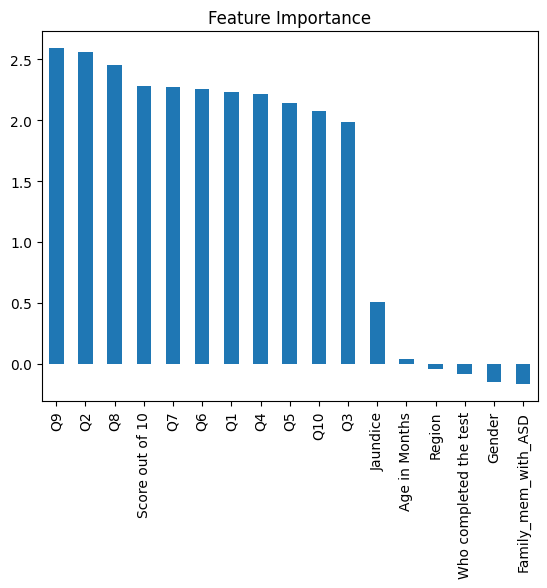

In [12]:
# Feature importance
feature_dict = dict(zip(feature_names, lr.coef_[0]))
feature_df = pd.DataFrame.from_dict(feature_dict, orient='index', columns=['Coefficient'])
feature_df.sort_values(by='Coefficient', ascending=False).plot.bar(title="Feature Importance", legend=False)

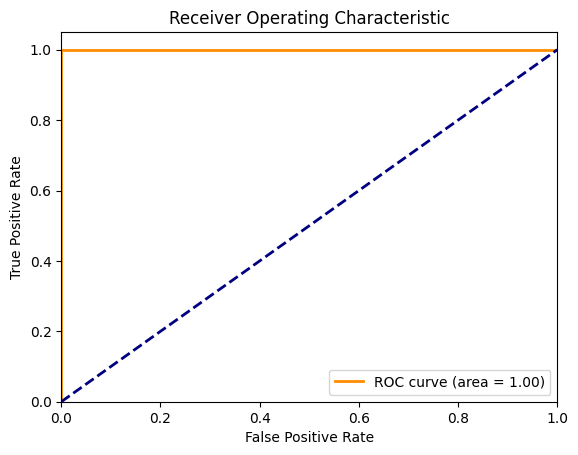

In [13]:
# ROC Curve
y_pred_proba = lr.predict_proba(x_test_processed)[:, 1]
fpr, tpr, _ = roc_curve(y_test_processed, y_pred_proba)
roc_auc = roc_auc_score(y_test_processed, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

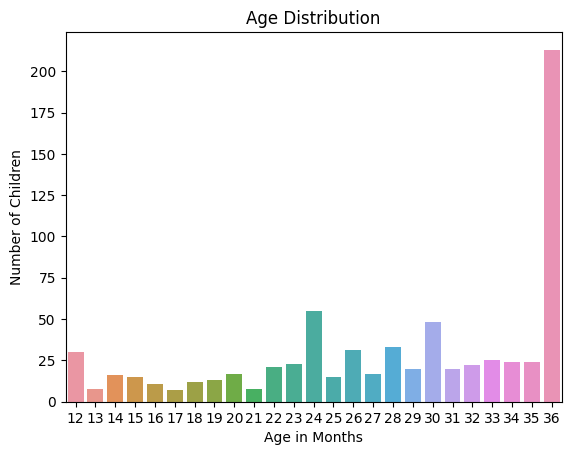

In [14]:
# Additional visualizations
yes_autism = df[df['ASD'] == 'Yes']
plt.figure()
sns.countplot(x="Age in Months", data=yes_autism)
plt.ylabel('Number of Children')
plt.title('Age Distribution')
plt.show()

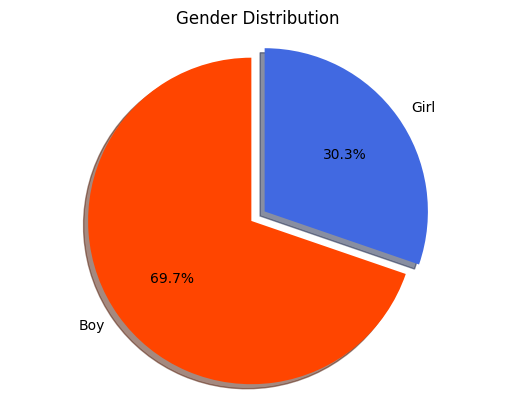

In [15]:
plt.figure()
plt.pie(df['Gender'].value_counts(), labels=['Boy', 'Girl'], explode=[0.1, 0], autopct='%1.1f%%', shadow=True, startangle=90, colors=['orangered', 'royalblue'])
plt.axis('equal')
plt.title('Gender Distribution')
plt.show()

In [16]:
import joblib

# Save the model
joblib.dump(lr, 'logistic_regression_model.pkl')
print("Model Save Successfully")

Model Save Successfully


## Comparison with Other Machine Learning Models

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC(probability=True)
}

# Dictionary to store model performance
model_performance = {}

# Train and evaluate each model
for name, model in models.items():
    model.fit(x_train_processed, y_train_processed)
    y_pred = model.predict(x_test_processed)
    y_pred_proba = model.predict_proba(x_test_processed)[:, 1]
    
    acc = accuracy_score(y_test_processed, y_pred)
    auc = roc_auc_score(y_test_processed, y_pred_proba)
    
    model_performance[name] = {'Accuracy': acc, 'ROC AUC': auc}
    print(f"{name} - Accuracy: {acc:.4f}, ROC AUC: {auc:.4f}")

# Determine the best model based on ROC AUC
best_model_name = max(model_performance, key=lambda x: model_performance[x]['ROC AUC'])
best_model = models[best_model_name]

print(f'\nBest Model: {best_model_name} - ROC AUC: {model_performance[best_model_name]["ROC AUC"]:.4f}')


Logistic Regression - Accuracy: 1.0000, ROC AUC: 1.0000
K-Nearest Neighbors - Accuracy: 0.9668, ROC AUC: 0.9907
Decision Tree - Accuracy: 1.0000, ROC AUC: 1.0000
Random Forest - Accuracy: 1.0000, ROC AUC: 1.0000
Support Vector Machine - Accuracy: 0.9810, ROC AUC: 0.9996

Best Model: Logistic Regression - ROC AUC: 1.0000


In [18]:
# Save the best model
import joblib
joblib.dump(best_model, 'best_model.pkl')
print(f"Saved the best model as 'best_model.pkl'")


Saved the best model as 'best_model.pkl'


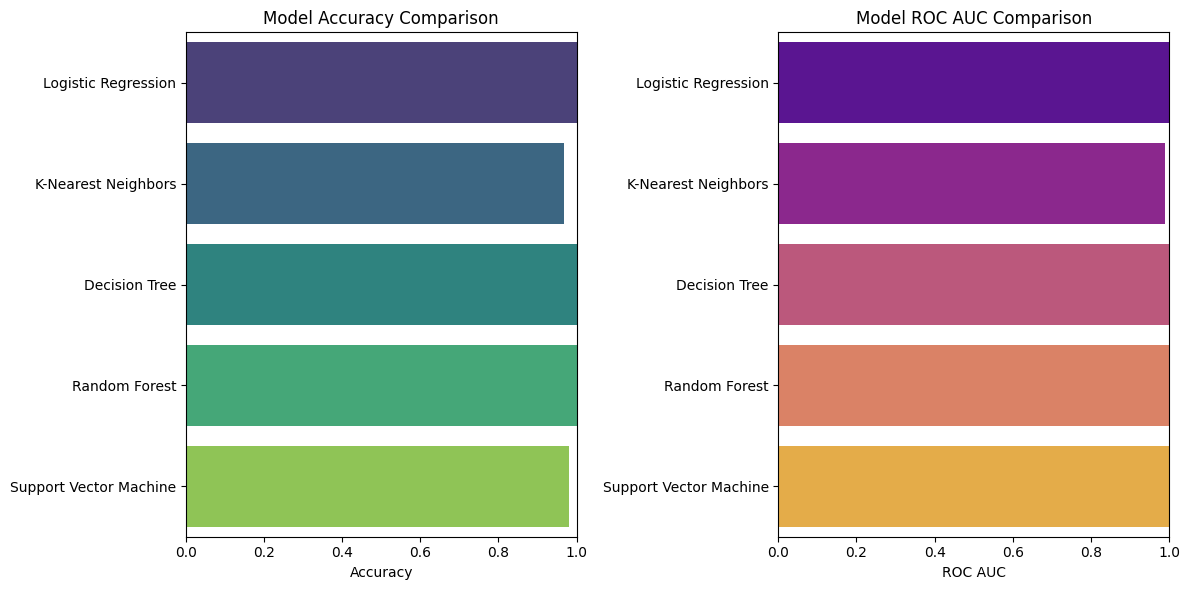

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract model names, accuracy, and ROC AUC scores
model_names = list(model_performance.keys())
accuracy_scores = [model_performance[model]['Accuracy'] for model in model_names]
roc_auc_scores = [model_performance[model]['ROC AUC'] for model in model_names]

# Set up the matplotlib figure
plt.figure(figsize=(12, 6))

# Plot accuracy scores
plt.subplot(1, 2, 1)
sns.barplot(x=accuracy_scores, y=model_names, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.xlim(0, 1)  # Assuming accuracy is between 0 and 1

# Plot ROC AUC scores
plt.subplot(1, 2, 2)
sns.barplot(x=roc_auc_scores, y=model_names, palette='plasma')
plt.title('Model ROC AUC Comparison')
plt.xlabel('ROC AUC')
plt.xlim(0, 1)  # Assuming ROC AUC is between 0 and 1

# Adjust layout
plt.tight_layout()
plt.show()
